In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pywt

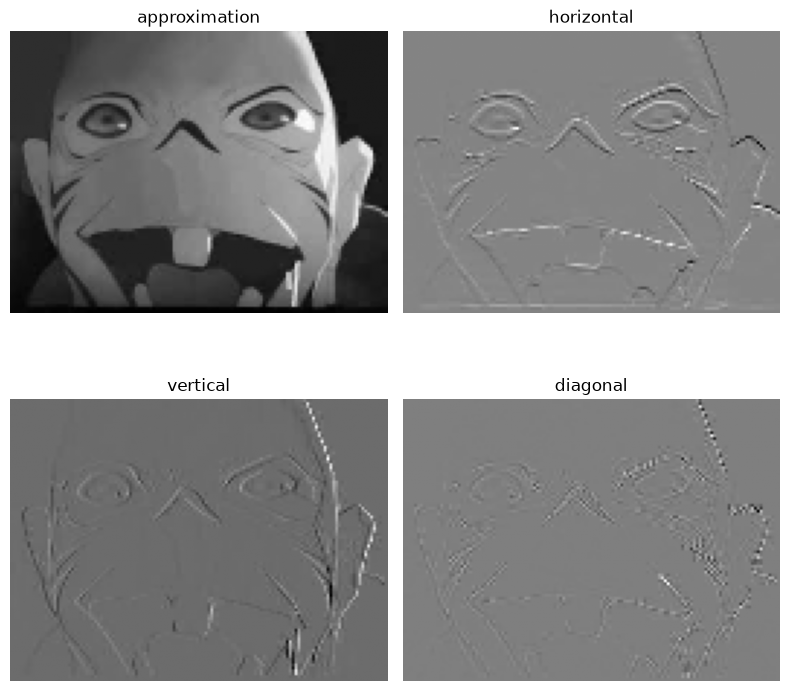

max reconstruction error: 4.5776367e-05


In [2]:
# WAVELETS (pywt)
# fourier tells you which frequencies, wavelets tell you which frequencies AND where (time / space)
# CWT: continuous scales, good for analysis of non stationary signals (morlet, mexh)
# DWT: discrete, dyadic scales. wavelets haar, db1..db20, sym, coif. used for compression, denoising, feature extraction
# WPT: DWT but also decomposes the detail coefficients -> full tree of subbands
# IDWT: reconstruct from coefficients
#
# dwt2 returns (cA, (cH, cV, cD)): approximation (low-low), horizontal, vertical, diagonal details

img = cv2.imread("Sukuna.jpg", cv2.IMREAD_GRAYSCALE)
img = np.float32(img)

cA, (cH, cV, cD) = pywt.dwt2(img, "haar")

plt.figure(figsize=(8, 8))
for i, (a, t) in enumerate(zip([cA, cH, cV, cD], ["approximation", "horizontal", "vertical", "diagonal"])):
    plt.subplot(2, 2, i + 1)
    plt.imshow(a, cmap="gray")
    plt.title(t)
    plt.axis("off")
plt.tight_layout()
plt.show()

# inverse
recon = pywt.idwt2((cA, (cH, cV, cD)), "haar")
recon = recon[:img.shape[0], :img.shape[1]]  # odd sizes come back padded by 1
print("max reconstruction error:", np.abs(recon - img).max())

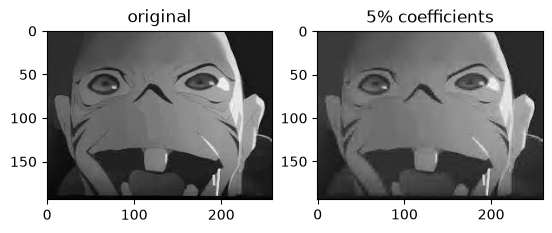

In [3]:
# multi level 2D DWT and image compression (throw away small coefficients)

coeffs = pywt.wavedec2(img, "db2", level=3)   # [cA3, (cH3, cV3, cD3), (cH2..), (cH1..)]
arr, slices = pywt.coeffs_to_array(coeffs)

# keep only the largest 5 percent of coefficients
thresh = np.percentile(np.abs(arr), 95)
arr_c = pywt.threshold(arr, thresh, mode="hard")

coeffs_c = pywt.array_to_coeffs(arr_c, slices, output_format="wavedec2")
img_c = pywt.waverec2(coeffs_c, "db2")

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("original")
plt.subplot(1, 2, 2)
plt.imshow(img_c, cmap="gray")
plt.title("5% coefficients")
plt.show()

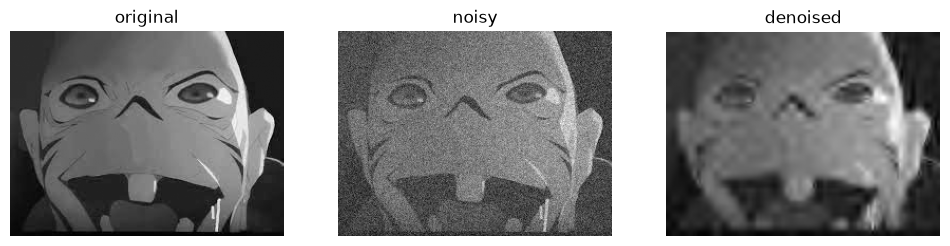

In [4]:
# wavelet denoising: add noise, soft threshold the detail coeffs, reconstruct
# universal threshold: sigma * sqrt(2 * log(n)), with sigma estimated from the finest diagonal band: median(|cD1|) / 0.6745

noisy = img + np.random.normal(0, 25, img.shape)

coeffs = pywt.wavedec2(noisy, "db4", level=3)
sigma = np.median(np.abs(coeffs[-1][2])) / 0.6745
t = sigma * np.sqrt(2 * np.log(noisy.size))

new_coeffs = [coeffs[0]]  # keep approximation
for details in coeffs[1:]:
    new_coeffs.append(tuple(pywt.threshold(d, t, mode="soft") for d in details))

denoised = pywt.waverec2(new_coeffs, "db4")

plt.figure(figsize=(12, 4))
for i, (a, t_) in enumerate(zip([img, noisy, denoised], ["original", "noisy", "denoised"])):
    plt.subplot(1, 3, i + 1)
    plt.imshow(a, cmap="gray")
    plt.title(t_)
    plt.axis("off")
plt.show()

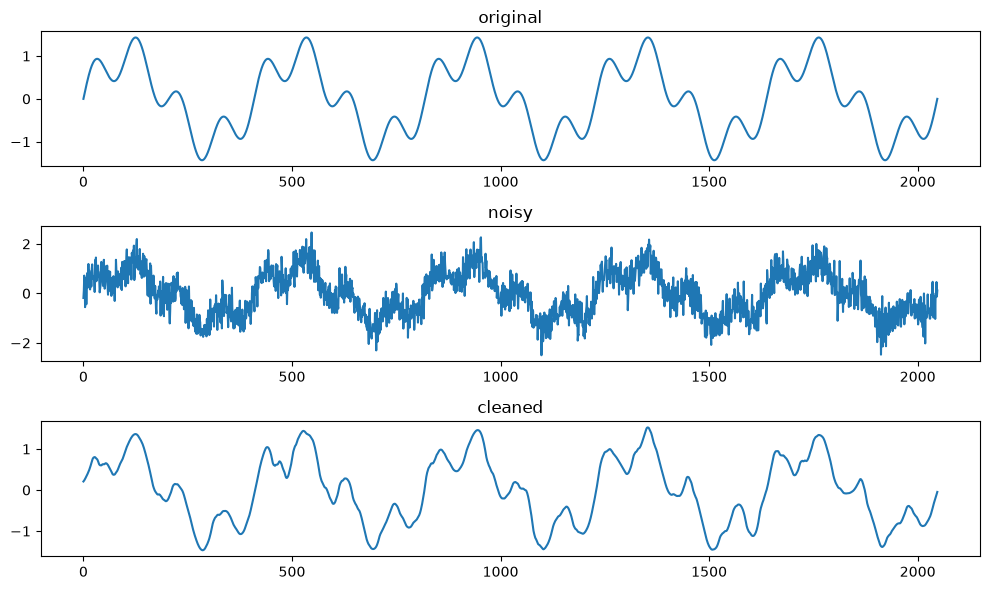

In [5]:
# 1D DWT: signal / audio denoising (the manual figure: original / noisy / cleaned audio)

t = np.linspace(0, 1, 2048)
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 20 * t)
noisy_sig = signal + np.random.normal(0, 0.4, t.shape)

coeffs = pywt.wavedec(noisy_sig, "db4", level=4)
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
thr = sigma * np.sqrt(2 * np.log(len(noisy_sig)))
coeffs[1:] = [pywt.threshold(c, thr, mode="soft") for c in coeffs[1:]]
clean_sig = pywt.waverec(coeffs, "db4")

plt.figure(figsize=(10, 6))
for i, (s, n) in enumerate(zip([signal, noisy_sig, clean_sig], ["original", "noisy", "cleaned"])):
    plt.subplot(3, 1, i + 1)
    plt.plot(s)
    plt.title(n)
plt.tight_layout()
plt.show()

# for real audio: from scipy.io import wavfile; rate, data = wavfile.read("x.wav")

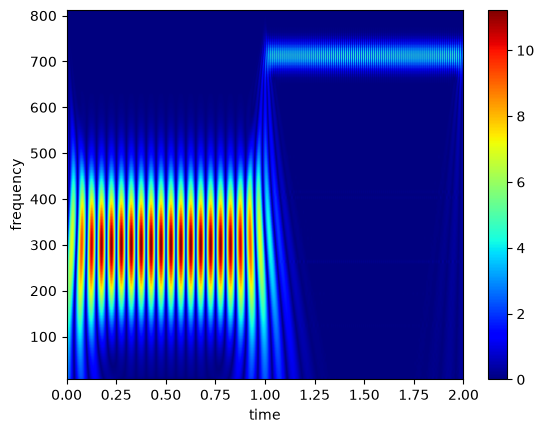

In [6]:
# CWT: time frequency (scalogram) of a non stationary signal. wavelets: "morl", "mexh", "gaus1", "cmor1.5-1.0"

sr = 1000
t = np.arange(0, 2, 1 / sr)
sig = np.where(t < 1, np.sin(2 * np.pi * 10 * t), np.sin(2 * np.pi * 50 * t))  # 10 Hz then 50 Hz

scales = np.arange(1, 128)
coef, freqs = pywt.cwt(sig, scales, "morl", sampling_period=1 / sr)

plt.imshow(np.abs(coef), aspect="auto", extent=[0, 2, freqs[-1], freqs[0]], cmap="jet")
plt.xlabel("time")
plt.ylabel("frequency")
plt.colorbar()
plt.show()

['aaa', 'aad', 'add', 'ada', 'dda', 'ddd', 'dad', 'daa']


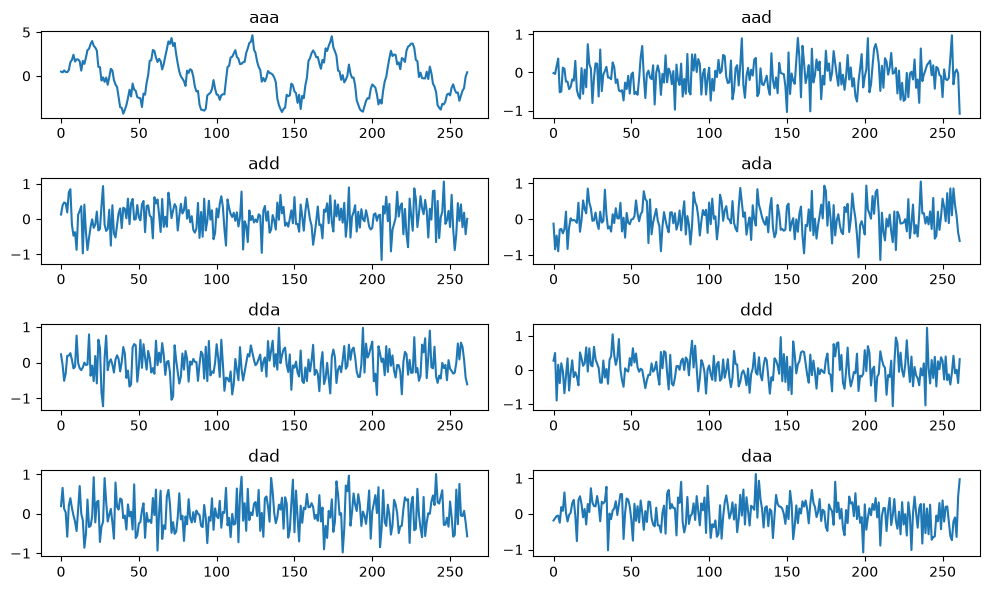

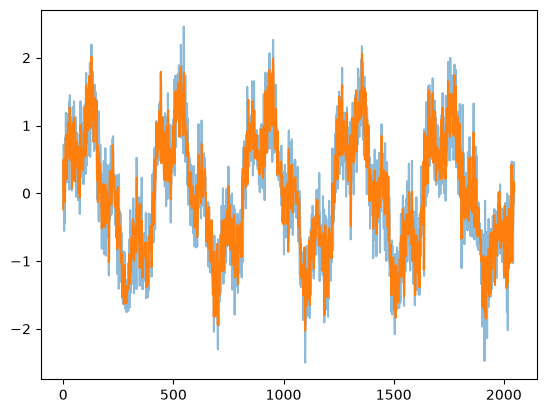

In [7]:
# Wavelet Packet Transform: decompose BOTH approximation and detail at every level -> 2^level subbands

wp = pywt.WaveletPacket(data=noisy_sig, wavelet="db4", mode="symmetric", maxlevel=3)

print([n.path for n in wp.get_level(3, order="freq")])  # subbands ordered by frequency ('aaa', 'aad', ...)

plt.figure(figsize=(10, 6))
for i, node in enumerate(wp.get_level(3, order="freq")):
    plt.subplot(4, 2, i + 1)
    plt.plot(node.data)
    plt.title(node.path)
plt.tight_layout()
plt.show()

# reconstruct from packet: zero the high freq nodes and reconstruct
wp2 = pywt.WaveletPacket(data=noisy_sig, wavelet="db4", mode="symmetric", maxlevel=3)
for node in wp2.get_level(3, order="freq")[4:]:
    wp2[node.path].data = np.zeros_like(node.data)
lowpassed = wp2.reconstruct(update=False)

plt.plot(noisy_sig, alpha=0.5)
plt.plot(lowpassed)
plt.show()

# 2D: pywt.WaveletPacket2D(data=img, wavelet="haar", maxlevel=2)

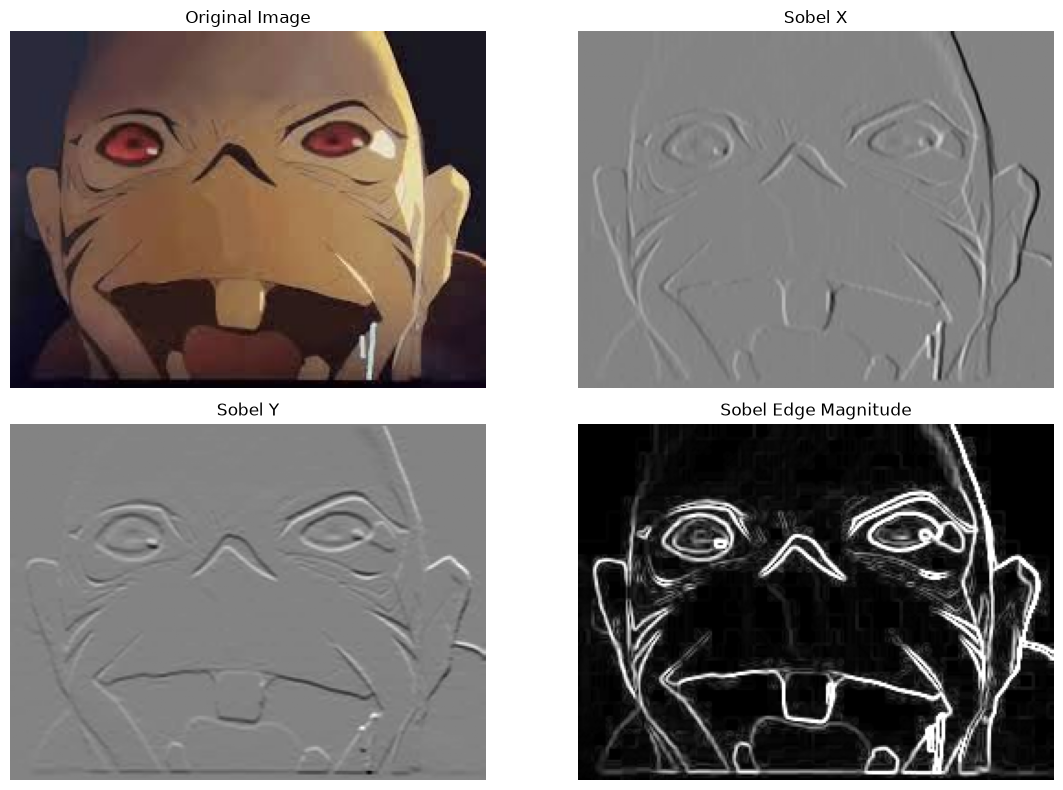

In [8]:
# BOUNDARY / EDGE DETECTION
# edge = significant change in intensity. first derivative (gradient peak) or second derivative (zero crossing)

img = cv2.imread("Sukuna.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# SOBEL: gx kernel [[-1,0,1],[-2,0,2],[-1,0,1]], gy is its transpose-ish. magnitude G = sqrt(gx^2 + gy^2), direction = arctan2(gy, gx)
# use CV_64F so negative gradients are not clipped
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
magnitude = np.uint8(np.clip(magnitude, 0, 255))
direction = np.arctan2(sobel_y, sobel_x) * 180 / np.pi

plt.figure(figsize=(12, 8))
for i, (a, t, cm) in enumerate([(img_rgb, "Original Image", None), (sobel_x, "Sobel X", "gray"),
                                (sobel_y, "Sobel Y", "gray"), (magnitude, "Sobel Edge Magnitude", "gray")]):
    plt.subplot(2, 2, i + 1)
    plt.imshow(a, cmap=cm)
    plt.title(t)
    plt.axis("off")
plt.tight_layout()
plt.show()

# same thing by hand with filter2D
kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
ky = kx.T
gx = cv2.filter2D(gray.astype(np.float32), -1, kx)  # filter2D is correlation, sign flip vs convolution doesn't matter for magnitude
gy = cv2.filter2D(gray.astype(np.float32), -1, ky)

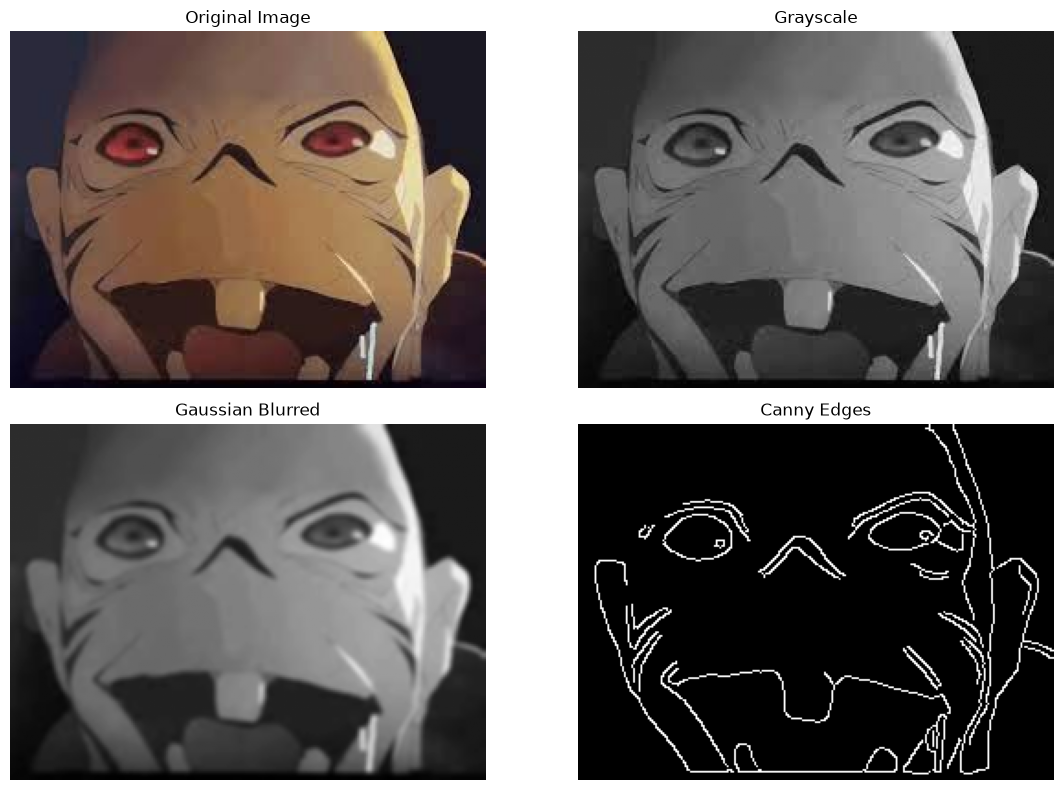

In [9]:
# CANNY: 1) gaussian smoothing 2) gradient magnitude + direction 3) non max suppression (thin edges)
#        4) hysteresis: > high = strong edge, < low = discard, in between kept only if connected to strong edge

blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)
edges = cv2.Canny(blurred, 50, 150)  # lower, upper threshold (typically upper = 2-3x lower)

plt.figure(figsize=(12, 8))
for i, (a, t) in enumerate([(img_rgb, "Original Image"), (gray, "Grayscale"), (blurred, "Gaussian Blurred"), (edges, "Canny Edges")]):
    plt.subplot(2, 2, i + 1)
    plt.imshow(a, cmap="gray")
    plt.title(t)
    plt.axis("off")
plt.tight_layout()
plt.show()

# auto threshold using median of the image
v = np.median(gray)
sigma = 0.33
auto_edges = cv2.Canny(blurred, int(max(0, (1 - sigma) * v)), int(min(255, (1 + sigma) * v)))

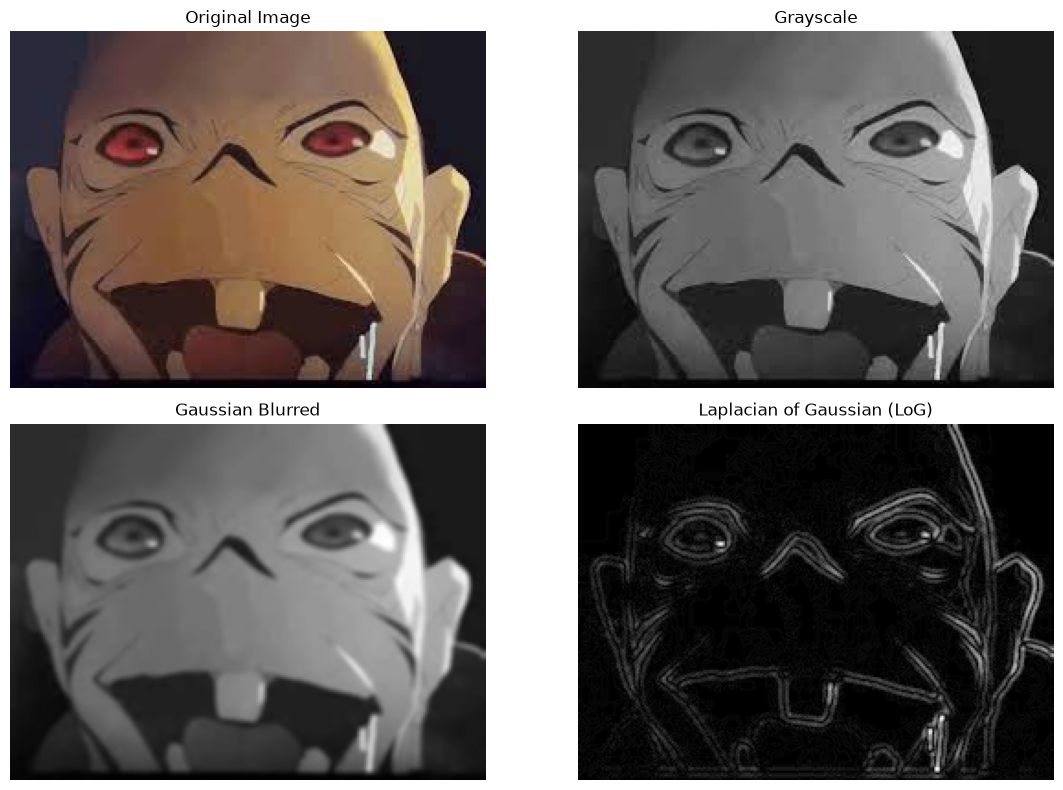

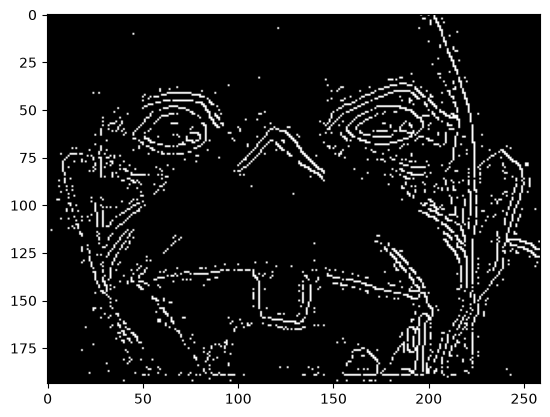

In [10]:
# LAPLACIAN OF GAUSSIAN (LoG): blur then second derivative. edges are at ZERO CROSSINGS of the result

blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)
laplacian = cv2.Laplacian(blurred, cv2.CV_64F)
laplacian_abs = cv2.convertScaleAbs(laplacian)

plt.figure(figsize=(12, 8))
for i, (a, t) in enumerate([(img_rgb, "Original Image"), (gray, "Grayscale"), (blurred, "Gaussian Blurred"), (laplacian_abs, "Laplacian of Gaussian (LoG)")]):
    plt.subplot(2, 2, i + 1)
    plt.imshow(a, cmap="gray")
    plt.title(t)
    plt.axis("off")
plt.tight_layout()
plt.show()

# zero crossing detection: a pixel is an edge if its sign differs from a neighbor (and the jump is large enough)
def zero_crossings(lap, thresh=0.0):
    out = np.zeros(lap.shape, np.uint8)
    right = lap[:, :-1] * lap[:, 1:] < 0
    down = lap[:-1, :] * lap[1:, :] < 0
    out[:, :-1] |= (right & (np.abs(lap[:, :-1] - lap[:, 1:]) > thresh)).astype(np.uint8)
    out[:-1, :] |= (down & (np.abs(lap[:-1, :] - lap[1:, :]) > thresh)).astype(np.uint8)
    return out * 255

plt.imshow(zero_crossings(laplacian, thresh=5), cmap="gray")
plt.show()

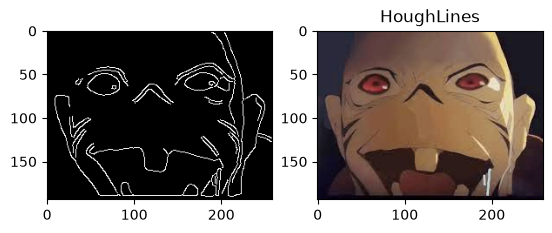

In [11]:
# HOUGH TRANSFORM: edge map -> parameter space voting -> peaks are shapes
# line: y = mx + b is bad for vertical lines so use normal form rho = x cos(theta) + y sin(theta). each edge pixel votes for all (rho, theta)
# circle: (x-a)^2 + (y-b)^2 = r^2 -> 3D accumulator (a, b, r)

edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 1.4), 50, 150)

# standard hough: returns (rho, theta) of lines with >= threshold votes
# args: edges, rho resolution (px), theta resolution (rad), vote threshold
lines = cv2.HoughLines(edges, 1, np.pi / 180, 150)

out = img_rgb.copy()
if lines is not None:
    for rho, theta in lines.reshape(-1, 2):  # opencv 4 gives (n,1,2), reshape works for both
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho
        p1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * a))
        p2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * a))
        cv2.line(out, p1, p2, (255, 0, 0), 2)

plt.subplot(1, 2, 1)
plt.imshow(edges, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(out)
plt.title("HoughLines")
plt.show()

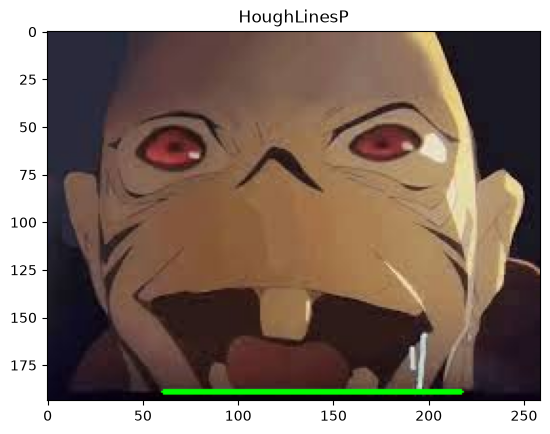

In [12]:
# probabilistic hough: returns segments (x1, y1, x2, y2) instead of infinite lines. faster
# minLineLength: min segment length, maxLineGap: max gap between points on same line to link them

lines_p = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=80, minLineLength=50, maxLineGap=10)

out = img_rgb.copy()
if lines_p is not None:
    for x1, y1, x2, y2 in lines_p.reshape(-1, 4):  # (n,1,4) in opencv 4, (n,4) in 5
        cv2.line(out, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.imshow(out)
plt.title("HoughLinesP")
plt.show()

14 lines


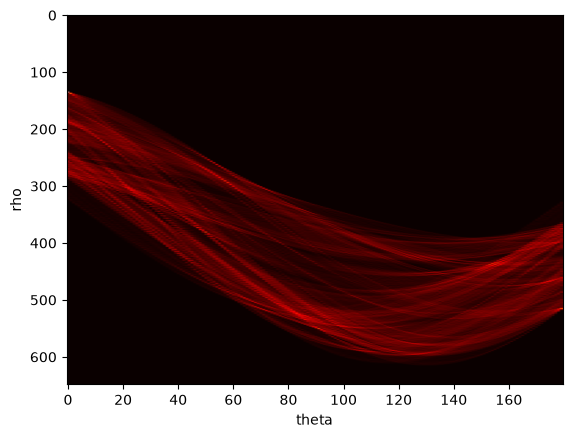

In [13]:
# hough line from scratch (accumulator in rho-theta space). good for "implement without cv2.HoughLines" questions

def hough_lines_manual(edge_img, theta_res=1, threshold=100):
    h, w = edge_img.shape
    thetas = np.deg2rad(np.arange(-90, 90, theta_res))
    diag = int(np.ceil(np.hypot(h, w)))
    rhos = np.arange(-diag, diag + 1)
    acc = np.zeros((len(rhos), len(thetas)), dtype=np.int32)

    ys, xs = np.nonzero(edge_img)
    cos_t, sin_t = np.cos(thetas), np.sin(thetas)
    for x, y in zip(xs, ys):
        r = np.round(x * cos_t + y * sin_t).astype(int) + diag  # one rho per theta
        acc[r, np.arange(len(thetas))] += 1

    peaks = np.argwhere(acc >= threshold)
    return acc, [(rhos[i], thetas[j]) for i, j in peaks]

acc, found = hough_lines_manual(edges, threshold=50)
print(len(found), "lines")

plt.imshow(acc, cmap="hot", aspect="auto")
plt.xlabel("theta")
plt.ylabel("rho")
plt.show()

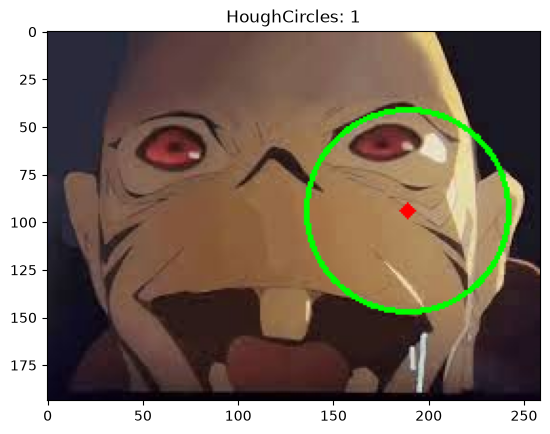

In [14]:
# hough circles: HOUGH_GRADIENT uses edge gradient to vote for centers first, then radius
# dp: inverse accumulator resolution, minDist: min distance between centers, param1: canny upper thr, param2: accumulator thr (lower = more circles)
# minRadius / maxRadius: limit search

blur = cv2.medianBlur(gray, 5)
circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=30, param1=100, param2=40, minRadius=10, maxRadius=100)

out = img_rgb.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for x, y, r in circles[0]:
        cv2.circle(out, (x, y), r, (0, 255, 0), 2)  # outline
        cv2.circle(out, (x, y), 2, (255, 0, 0), 3)   # center

plt.imshow(out)
plt.title(f"HoughCircles: {0 if circles is None else circles.shape[1]}")
plt.show()

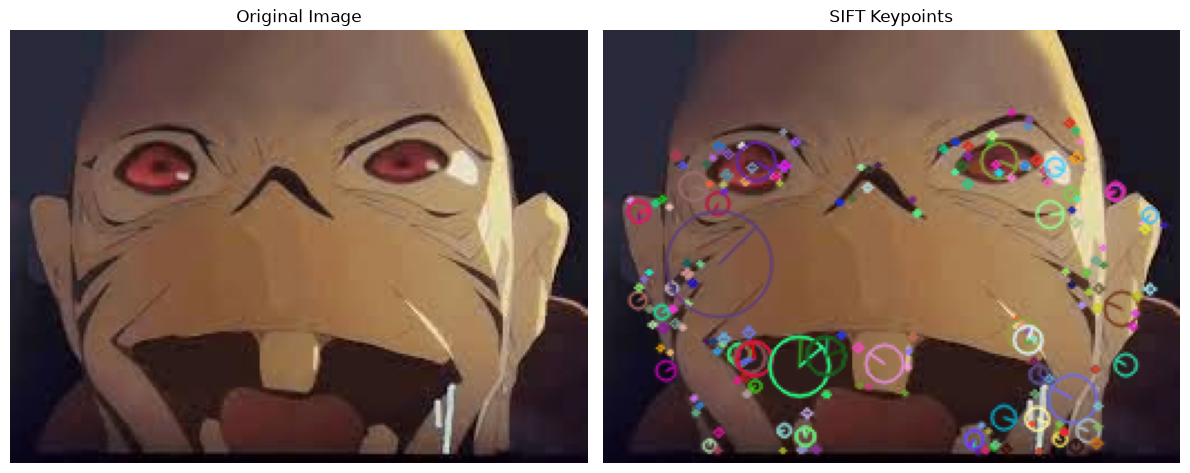

Number of keypoints: 223
Descriptor shape: (223, 128)
(12.178935050964355, 75.90020751953125) 2.39289927482605 48.312957763671875 0.02109694667160511


In [15]:
# SIFT (Scale Invariant Feature Transform)
# 1) scale space extrema: difference of gaussians (DoG) at multiple scales, pixel is a candidate if it is max/min vs its 26 neighbors (8 same layer + 9 above + 9 below)
# 2) keypoint localization: fit 3D quadratic, drop low contrast and edge-like points
# 3) orientation assignment: dominant gradient direction of the neighborhood -> rotation invariance
# 4) descriptor: 4x4 subregions x 8 orientation bins = 128 dim vector
# 5) matching: euclidean distance between descriptors + ratio test
# 6) outlier rejection: RANSAC -> homography

sift = cv2.SIFT_create()  # nfeatures, contrastThreshold=0.04, edgeThreshold=10, sigma=1.6
keypoints, descriptors = sift.detectAndCompute(gray, None)

image_keypoints = cv2.drawKeypoints(img_rgb, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)  # circle size = scale, line = orientation

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(image_keypoints)
plt.title("SIFT Keypoints")
plt.axis("off")
plt.tight_layout()
plt.show()

print("Number of keypoints:", len(keypoints))
print("Descriptor shape:", descriptors.shape)  # (n, 128)

kp = keypoints[0]
print(kp.pt, kp.size, kp.angle, kp.response)

225 -> 124 good matches
[[ 6.91996244e-01  4.00327516e-01  9.27197047e-01]
 [-4.01098169e-01  6.90727488e-01  8.20202814e+01]
 [-1.43827219e-06 -1.19972642e-06  1.00000000e+00]]
inliers: 115


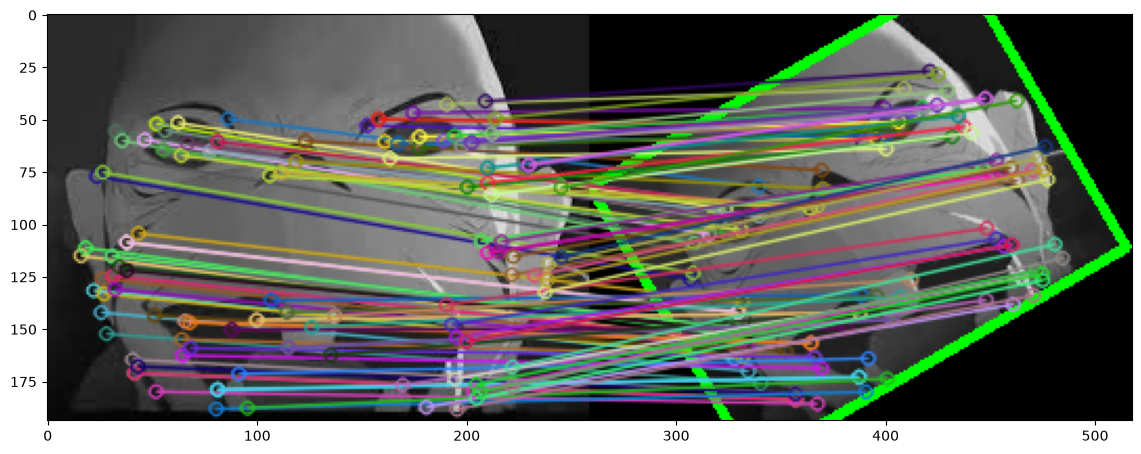

In [16]:
# keypoint matching + ratio test + RANSAC homography
# query image = img1 (object), train image = img2 (scene). here img2 is a rotated + scaled version of img1 so it works with one image;
# for the exam swap in the two real images

img1 = cv2.imread("Sukuna.jpg", cv2.IMREAD_GRAYSCALE)
h, w = img1.shape
M = cv2.getRotationMatrix2D((w / 2, h / 2), 30, 0.8)  # center, angle, scale
img2 = cv2.warpAffine(img1, M, (w, h))

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# brute force matcher, L2 norm for SIFT (use NORM_HAMMING for ORB/BRIEF/AKAZE binary descriptors)
bf = cv2.BFMatcher(cv2.NORM_L2)
knn = bf.knnMatch(des1, des2, k=2)

# lowe ratio test: best match must be clearly better than second best
good = [m for m, n in knn if m.distance < 0.75 * n.distance]
print(len(knn), "->", len(good), "good matches")

if len(good) >= 4:
    src = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    # RANSAC: repeatedly fit homography to 4 random matches, keep model with most inliers (reproj error < 5 px)
    H, inlier_mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    print(H)
    print("inliers:", inlier_mask.sum())

    # project the corners of img1 into img2
    corners = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)
    projected = cv2.perspectiveTransform(corners, H)
    img2_box = cv2.polylines(cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR), [np.int32(projected)], True, (0, 255, 0), 3)

    matches_img = cv2.drawMatches(img1, kp1, img2_box, kp2, good, None,
                                  matchesMask=inlier_mask.ravel().tolist(),
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(14, 6))
    plt.imshow(cv2.cvtColor(matches_img, cv2.COLOR_BGR2RGB))
    plt.show()

In [17]:
# image stitching with homography (panorama). H maps img_b -> img_a coordinates
# for the exam: load left and right images and call stitch()

def stitch(img_a, img_b):
    ga = cv2.cvtColor(img_a, cv2.COLOR_BGR2GRAY)
    gb = cv2.cvtColor(img_b, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    ka, da = sift.detectAndCompute(ga, None)
    kb, db = sift.detectAndCompute(gb, None)
    knn = cv2.BFMatcher(cv2.NORM_L2).knnMatch(db, da, k=2)
    good = [m for m, n in knn if m.distance < 0.75 * n.distance]
    src = np.float32([kb[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([ka[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, _ = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    pano = cv2.warpPerspective(img_b, H, (img_a.shape[1] + img_b.shape[1], img_a.shape[0]))
    pano[0:img_a.shape[0], 0:img_a.shape[1]] = img_a
    return pano

# pano = stitch(cv2.imread("left.jpg"), cv2.imread("right.jpg"))
# plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB)); plt.show()

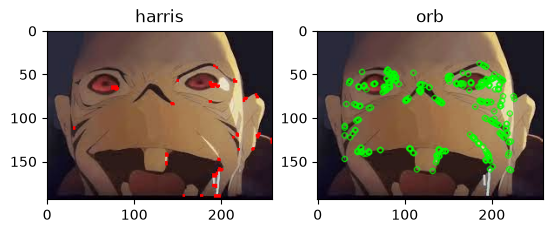

In [18]:
# extras that may show up: Harris corners, ORB (free alternative to sift, binary descriptors)

# harris: blockSize (neighborhood), ksize (sobel), k (0.04-0.06)
g = np.float32(gray)
harris = cv2.cornerHarris(g, blockSize=2, ksize=3, k=0.04)
harris = cv2.dilate(harris, None)
out = img_rgb.copy()
out[harris > 0.01 * harris.max()] = [255, 0, 0]

# orb
orb = cv2.ORB_create(nfeatures=500)
kp_orb, des_orb = orb.detectAndCompute(gray, None)
out_orb = cv2.drawKeypoints(img_rgb, kp_orb, None, color=(0, 255, 0))

plt.subplot(1, 2, 1)
plt.imshow(out)
plt.title("harris")
plt.subplot(1, 2, 2)
plt.imshow(out_orb)
plt.title("orb")
plt.show()

In [ ]:
# ===== LAB 06 TASK TEMPLATES (swap in the exam images) =====
# TASK: anomaly detection in sensor data with wavelets
# idea: wavelet denoise = smooth "normal" signal. residual = raw - denoised. residual that is unusually big = anomaly

np.random.seed(0)
sensor = np.random.normal(0, 1, 1000)

coeffs = pywt.wavedec(sensor, "db4", level=4)
coeffs[1:] = [np.zeros_like(c) for c in coeffs[1:]]  # kill all details -> keep only the smooth trend (manual plot looks like this)
denoised = pywt.waverec(coeffs, "db4")[:len(sensor)]

residual = sensor - denoised
thr = 2 * residual.std()  # or 3 * std, or mean + 3 * std
anom = np.where(np.abs(residual) > thr)[0]

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(sensor, label="Sensor Data")
plt.plot(denoised, "--", label="Denoised Signal")
plt.legend()
plt.title("Sensor Data and Denoised Signal")
plt.subplot(2, 1, 2)
plt.plot(residual, "r", label="Residuals")
plt.scatter(anom, residual[anom], c="g", label="Anomalies", zorder=3)
plt.legend()
plt.title("Residuals and Detected Anomalies")
plt.tight_layout()
plt.show()
# real data: sensor = pd.read_csv("x.csv")["col"].values  (or np.loadtxt)

In [ ]:
# TASK: lane detection with Hough lines
# gray -> blur -> canny -> keep only the road region (trapezoid mask) -> HoughLinesP -> draw

def detect_lanes(bgr):
    h, w = bgr.shape[:2]
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)

    roi = np.zeros_like(edges)
    poly = np.array([[(0, h), (w * 0.45, h * 0.6), (w * 0.55, h * 0.6), (w, h)]], dtype=np.int32)
    cv2.fillPoly(roi, poly, 255)
    edges = cv2.bitwise_and(edges, roi)

    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 50, minLineLength=40, maxLineGap=100)
    out = bgr.copy()
    if lines is not None:
        for x1, y1, x2, y2 in lines.reshape(-1, 4):
            if x2 != x1 and abs((y2 - y1) / (x2 - x1)) > 0.4:  # drop near-horizontal lines
                cv2.line(out, (x1, y1), (x2, y2), (0, 0, 255), 4)
    return out

road = cv2.imread("Sukuna.jpg")  # swap in road image
plt.imshow(cv2.cvtColor(detect_lanes(road), cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
# TASK: coin detection and counting with Hough circles
# median blur -> HoughCircles -> count = number of circles. tune minRadius/maxRadius to coin size, param2 (lower = more circles, more false ones)

def count_coins(bgr, min_r=15, max_r=80):
    gray = cv2.medianBlur(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY), 7)
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=gray.shape[0] // 10,
                               param1=100, param2=40, minRadius=min_r, maxRadius=max_r)
    out = bgr.copy()
    n = 0
    if circles is not None:
        circles = np.round(circles[0]).astype(int)
        n = len(circles)
        for x, y, r in circles:
            cv2.circle(out, (x, y), r, (0, 255, 0), 3)
            cv2.circle(out, (x, y), 2, (0, 0, 255), 3)
    cv2.putText(out, f"Coins: {n}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)
    return out, n

out, n = count_coins(cv2.imread("Sukuna.jpg"))
print("coins:", n)
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
# TASK: computer screen detection in a lab with Hough lines
# screens are rectangles = 2 sets of roughly horizontal + vertical lines. detect lines, keep near horizontal/vertical, draw them.
# to get actual rectangles: find contours on the edge map and keep cv2.approxPolyDP == 4 corners and big area (shown below)

def detect_screens(bgr, min_area=3000):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8))  # close small gaps in the borders

    out = bgr.copy()
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 80, minLineLength=60, maxLineGap=10)
    if lines is not None:
        for x1, y1, x2, y2 in lines.reshape(-1, 4):
            ang = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
            if ang < 10 or ang > 170 or abs(ang - 90) < 10:  # horizontal or vertical only
                cv2.line(out, (x1, y1), (x2, y2), (0, 255, 255), 2)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    screens = []
    for c in contours:
        approx = cv2.approxPolyDP(c, 0.02 * cv2.arcLength(c, True), True)
        if len(approx) == 4 and cv2.contourArea(approx) > min_area:
            screens.append(approx)
            cv2.drawContours(out, [approx], -1, (0, 255, 0), 3)
    print("screens found:", len(screens))  # compare with expected count -> missing screen = anomaly
    return out

plt.imshow(cv2.cvtColor(detect_screens(cv2.imread("Sukuna.jpg")), cv2.COLOR_BGR2RGB))
plt.show()
# on/off: mean brightness inside each screen quad. dark (< ~50) = off

In [ ]:
# TASK: object recognition with SIFT (reference image -> find it in test image(s) or video frames), bounding box

def find_object(ref_gray, scene_bgr, sift, ref_kp, ref_des, min_matches=10):
    scene_gray = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2GRAY)
    kp, des = sift.detectAndCompute(scene_gray, None)
    if des is None or len(kp) < 2:
        return scene_bgr, False
    knn = cv2.BFMatcher(cv2.NORM_L2).knnMatch(ref_des, des, k=2)
    good = [m for m, n in (p for p in knn if len(p) == 2) if m.distance < 0.75 * n.distance]
    out = scene_bgr.copy()
    if len(good) < min_matches:
        return out, False
    src = np.float32([ref_kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)  # RANSAC handles partial occlusion / outliers
    if H is None:
        return out, False
    h, w = ref_gray.shape
    box = cv2.perspectiveTransform(np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2), H)
    cv2.polylines(out, [np.int32(box)], True, (0, 255, 0), 4)
    return out, True

sift = cv2.SIFT_create()
ref = cv2.imread("Sukuna.jpg", cv2.IMREAD_GRAYSCALE)
ref_kp, ref_des = sift.detectAndCompute(ref, None)

# images: for path in ["a.jpg", "b.jpg"]: out, ok = find_object(ref, cv2.imread(path), sift, ref_kp, ref_des)
scene = cv2.warpAffine(cv2.imread("Sukuna.jpg"), cv2.getRotationMatrix2D((100, 100), 20, 0.7), (400, 400))
out, ok = find_object(ref, scene, sift, ref_kp, ref_des)
print("found:", ok)
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.show()

# VIDEO: same function per frame
# cap = cv2.VideoCapture("video.mp4")   (0 = webcam)
# while True:
#     ok, frame = cap.read()
#     if not ok: break
#     out, found = find_object(ref, frame, sift, ref_kp, ref_des)
#     cv2.imshow("result", out)
#     if cv2.waitKey(1) & 0xFF == ord("q"): break
# cap.release(); cv2.destroyAllWindows()
# (cv2.imshow may not work inside notebooks -> save frames or plt.imshow a few of them)

In [ ]:
# TASK: panorama (multiple images). stitch() above does 2 images. for many: fold left to right.
# or just use the built in stitcher:

def panorama_builtin(images):
    stitcher = cv2.Stitcher_create()  # cv2.Stitcher_PANORAMA by default
    status, pano = stitcher.stitch(images)
    return pano if status == cv2.Stitcher_OK else None  # status 1 = need more images, 2 = homography failed

# pano = panorama_builtin([cv2.imread(p) for p in ["1.jpg", "2.jpg", "3.jpg"]])

# manual fold: images must be ordered left to right
# pano = images[0]
# for nxt in images[1:]:
#     pano = stitch(pano, nxt)

In [ ]:
# TASK: smart security system. boundary detection of objects inside a predefined zone -> alarm
# idea: edges/contours (Canny + findContours) -> if a contour's bounding box overlaps the zone rect -> alarm
# better for video: background subtraction first (cv2.createBackgroundSubtractorMOG2) then contours of the foreground

ZONE = (100, 100, 300, 300)  # x1, y1, x2, y2

def check_zone(bgr, zone=ZONE, min_area=500):
    gray = cv2.GaussianBlur(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY), (5, 5), 0)
    edges = cv2.dilate(cv2.Canny(gray, 50, 150), np.ones((5, 5), np.uint8))
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    out = bgr.copy()
    x1, y1, x2, y2 = zone
    alarm = False
    for c in contours:
        if cv2.contourArea(c) < min_area:
            continue
        x, y, w, h = cv2.boundingRect(c)
        if x < x2 and x + w > x1 and y < y2 and y + h > y1:  # rectangles overlap
            alarm = True
            cv2.rectangle(out, (x, y), (x + w, y + h), (0, 0, 255), 2)
    cv2.rectangle(out, (x1, y1), (x2, y2), (0, 0, 255) if alarm else (0, 255, 0), 3)
    if alarm:
        cv2.putText(out, "ALARM!", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)
    return out, alarm

out, alarm = check_zone(cv2.imread("Sukuna.jpg"))
print("alarm:", alarm)
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.show()

# video version with background subtraction:
# bg = cv2.createBackgroundSubtractorMOG2(); per frame: fg = bg.apply(frame); then contours = findContours(fg > 200 ...)